In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

 
from translator_logic import translator 
from config import SUPPORTED_LANGS

In [2]:
import pandas as pd  

#  dataset for bot accuracy
test_data = [
    {"text": "Hello, how can I help?", "true_lang": "en"},
    {"text": "What is the price?", "true_lang": "en"},
    {"text": "नमस्ते, आप कैसे हैं?", "true_lang": "hi"},
    {"text": "मेरा नाम क्या है?", "true_lang": "hi"},
    {"text": "Hola, ¿cómo estás?", "true_lang": "es"},
    {"text": "Gracias por tu ayuda", "true_lang": "es"},
    {"text": "Bonjour, comment ça va?", "true_lang": "fr"},
    {"text": "नमस्कार, मी तुम्हाला कशी मदत करू शकतो?", "true_lang": "mr"}
]

df = pd.DataFrame(test_data)
print("Test Dataset Loaded:")
display(df.head())

Test Dataset Loaded:


,text,true_lang
0,"Hello, how can I help?",en
1,What is the price?,en
2,"नमस्ते, आप कैसे हैं?",hi
3,मेरा नाम क्या है?,hi
4,"Hola, ¿cómo estás?",es


In [3]:

def predict_language(text):
    try:
        return translator.detect(text).lang
    except Exception as e:
        return "error"
 
df['predicted_lang'] = df['text'].apply(predict_language)
display(df)

,text,true_lang,predicted_lang
0,"Hello, how can I help?",en,error
1,What is the price?,en,error
2,"नमस्ते, आप कैसे हैं?",hi,error
3,मेरा नाम क्या है?,hi,error
4,"Hola, ¿cómo estás?",es,error
5,Gracias por tu ayuda,es,error
6,"Bonjour, comment ça va?",fr,error
7,"नमस्कार, मी तुम्हाला कशी मदत करू शकतो?",mr,error


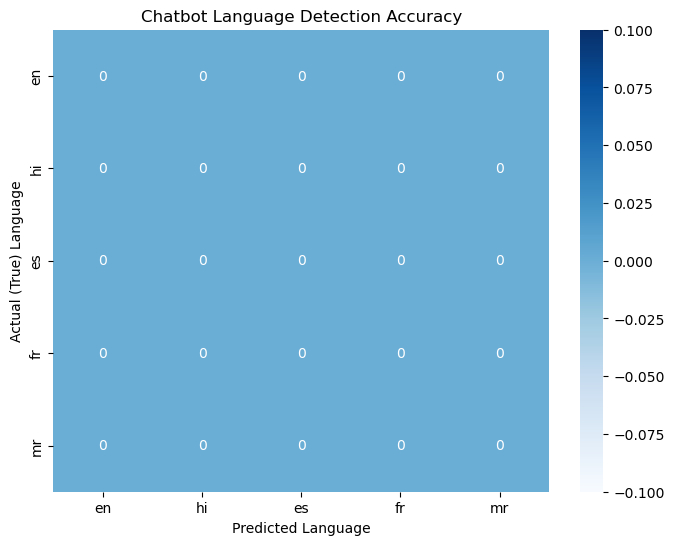


--- Detailed Classification Report ---
              precision    recall  f1-score   support

          en       0.00      0.00      0.00       2.0
          hi       0.00      0.00      0.00       2.0
          es       0.00      0.00      0.00       2.0
          fr       0.00      0.00      0.00       1.0
          mr       0.00      0.00      0.00       1.0

   micro avg       0.00      0.00      0.00       8.0
   macro avg       0.00      0.00      0.00       8.0
weighted avg       0.00      0.00      0.00       8.0



In [5]:
 
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
 

 
labels = ['en', 'hi', 'es', 'fr', 'mr']

#  Confusion Matrix
cm = confusion_matrix(df['true_lang'], df['predicted_lang'], labels=labels)

#  Plot the Matrix 
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=labels, yticklabels=labels)

plt.title('Chatbot Language Detection Accuracy')
plt.xlabel('Predicted Language')
plt.ylabel('Actual (True) Language')
plt.show()

# metrics report
print("\n--- Detailed Classification Report ---")
print(classification_report(df['true_lang'], df['predicted_lang'], labels=labels, zero_division=0))